<a href="https://colab.research.google.com/github/felipe-lim4/study-ml-regression/blob/main/analise_e_selecao_de_modelo_de_regressao_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praticando análise e seleção de modelos de regressão linear
Criação modelo de predição de precificação de quartos de hotéis, fazendo uso do conjunto de dados fornecidos.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd

In [9]:
data = pd.read_csv('/content/drive/MyDrive/fontes/hoteis.csv')
data.info()
# Todas as varivaveis estão em valores numericos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Estrelas            1000 non-null   int64  
 1   ProximidadeTurismo  1000 non-null   float64
 2   Capacidade          1000 non-null   int64  
 3   Preco               1000 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 31.4 KB


In [13]:
# Identificando correlação de variaveis:
correlacao = data.corr()
correlacao['Preco']

,Preco
Estrelas,0.401099
ProximidadeTurismo,-0.697142
Capacidade,0.531866
Preco,1.000000


Identificado que proximidade de turismo é inversamente proporcional ao preço e está altamente relacionado eu preço, as outras são correlações mais moderadas, mas que são mais proporcionais

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

##### heatmap
Aqui vamos fazer o gráfico de correlação, que tem como objetivo identificar quais variaveis podem possuir uma multicolinearidade, ja que podem estár diretamente relacionados

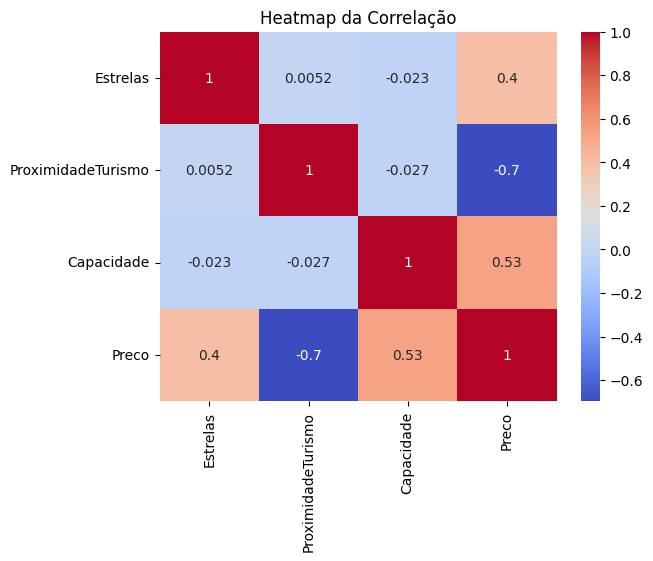

In [19]:
sns.heatmap(correlacao, annot=True, cmap='coolwarm')
plt.title('Heatmap da Correlação')
plt.show()

Nesse caso, da para ver que a variavel alvo (preco), tem certa relação com todas as variaveis explicativas, no entanto, também é possivel notar uma relação inversamente proporcional entre estreals e proximidade de turismo, que pode ser ou não o acaso. Por isso podemos usar o scatter para verificar isso

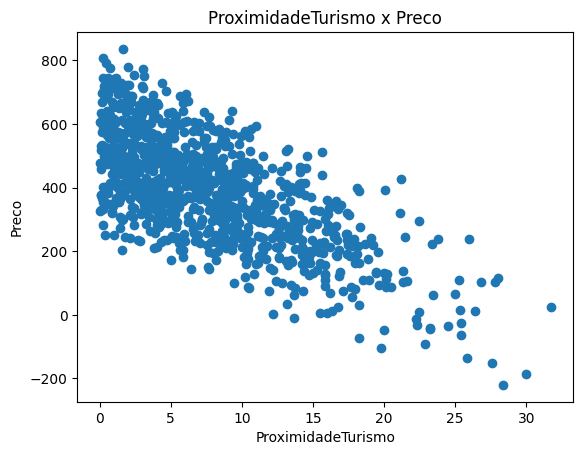

In [20]:
plt.scatter(data['ProximidadeTurismo'], data['Preco'])
plt.title('ProximidadeTurismo x Preco')
plt.xlabel('ProximidadeTurismo')
plt.ylabel('Preco')
plt.show()

In [ ]:
Observavel linearidade negativa na proximidade turismo

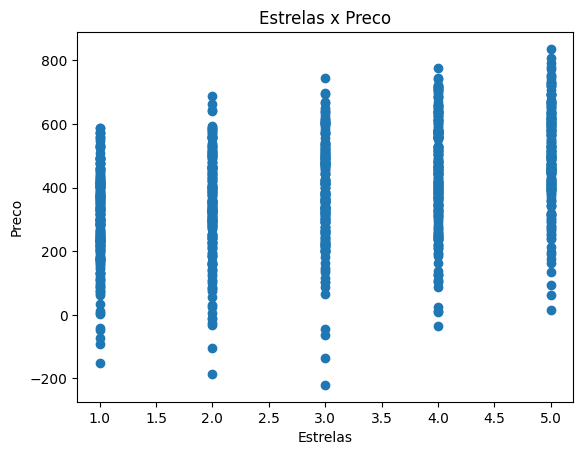

In [26]:
plt.scatter(data['Estrelas'], data['Preco'])
plt.title('Estrelas x Preco')
plt.xlabel('Estrelas')
plt.ylabel('Preco')
plt.show()

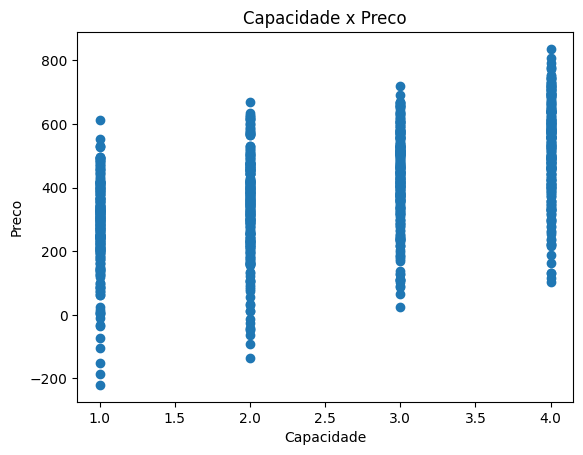

In [28]:
plt.scatter(data['Capacidade'], data['Preco'])
plt.title('Capacidade x Preco')
plt.xlabel('Capacidade')
plt.ylabel('Preco')
plt.show()

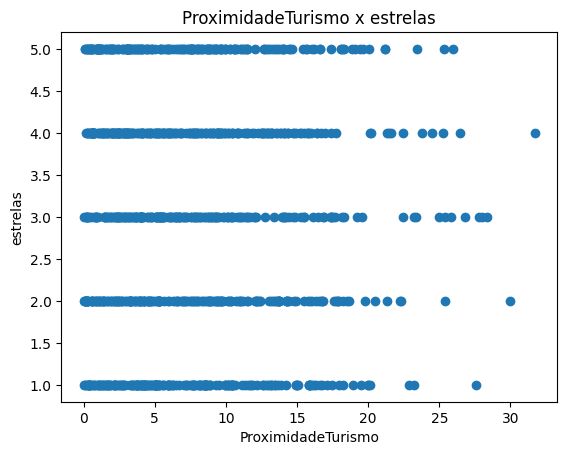

In [22]:
plt.scatter(data['ProximidadeTurismo'], data['Estrelas'])
plt.title('ProximidadeTurismo x estrelas')
plt.xlabel('ProximidadeTurismo')
plt.ylabel('estrelas')
plt.show()

In [24]:
import plotly.express as px

In [31]:
px.scatter(data, x='ProximidadeTurismo', y='Preco', trendline_color_override="red", trendline='ols')

Linearidade clara entre os dois, com R² de o,48, então possivelmente esse preço é 40% decidido apenas pela proximidade. O que faz bastante sentido se pensarmos na vida real, quando mais longe do turismo, mais barato será! No entanto da para perceber há muito mais dados referentes a proximidades mais baixas, vamos dar uma olhada nisso:

Text(0.5, 1.0, 'Distribuição de Proximidade de Turismo')

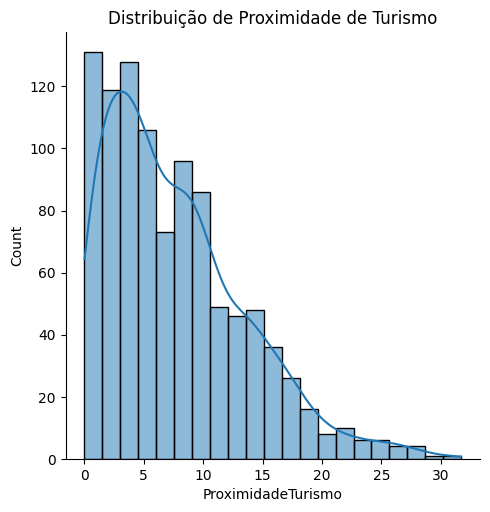

In [38]:
sns.displot(data['ProximidadeTurismo'], kde=True)
plt.title('Distribuição de Proximidade de Turismo')

In [ ]:
Disparidade enorme de dados, provavelmente deve dar algum tipo de problema de desempenho, especialmente em dados acima de 10 de proximidade de turismo

Separação de dados!

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
y = data['Preco']
x = data.drop('Preco', axis=1)

In [42]:
x_treino,x_teste, y_treino,y_teste = train_test_split(x,y,test_size=0.3, random_state=42)

In [46]:
df_treino = pd.DataFrame(data=x_treino)
df_treino['Preco'] = y_treino